<a href="https://colab.research.google.com/github/lahya-2006/spam-filter-naive-bayes/blob/main/Spam_Filter_Naive_Bayes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
#upload the dataset
from google.colab import files

uploaded = files.upload()

Saving spam.csv to spam.csv


In [3]:
print(uploaded.keys())

dict_keys(['spam.csv'])


In [4]:
#Load the Dataset
df = pd.read_csv(
    "spam.csv",
    encoding="latin-1"
)

df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [5]:
#check Dataset Columns
print(df.columns)

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')


In [6]:
#Remove Unnecessary Columns
df = df[['v1', 'v2']]

df.columns = ['label', 'message']

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [7]:
#Explore Dataset Information
print("Dataset Shape:", df.shape)

print("\nDataset Information:")
df.info()

Dataset Shape: (5572, 2)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [8]:
#Check for Missing Values
print(df.isnull().sum())

label      0
message    0
dtype: int64


In [9]:
df = df.dropna()
print(df.isnull().sum())

label      0
message    0
dtype: int64


In [10]:
#Remove Duplicate Messages
print("Before removing duplicates:", df.shape)

df = df.drop_duplicates()

print("After removing duplicates:", df.shape)

Before removing duplicates: (5572, 2)
After removing duplicates: (5169, 2)


In [11]:
#Analyze Spam and Ham Messages
print(df['label'].value_counts())

label
ham     4516
spam     653
Name: count, dtype: int64


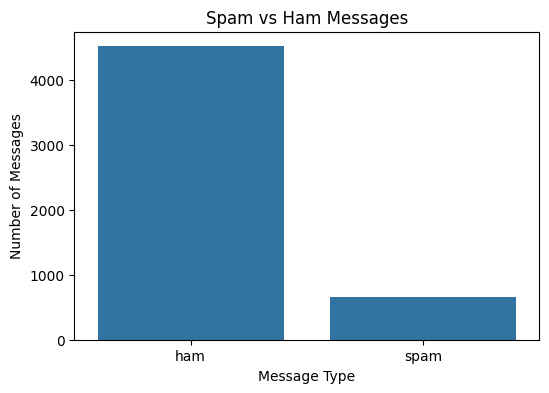

In [12]:
#Visualize Spam and Ham Messages
plt.figure(figsize=(6,4))

sns.countplot(data=df, x='label')

plt.title("Spam vs Ham Messages")
plt.xlabel("Message Type")
plt.ylabel("Number of Messages")

plt.show()

In [13]:
#Text preprocessing
df['message'] = df['message'].str.lower()

df.head()

,label,message
0,ham,"go until jurong point, crazy.. available only ..."
1,ham,ok lar... joking wif u oni...
2,spam,free entry in 2 a wkly comp to win fa cup fina...
3,ham,u dun say so early hor... u c already then say...
4,ham,"nah i don't think he goes to usf, he lives aro..."


In [14]:
#Convert Labels into Numerical Values
df['label_num'] = df['label'].map({
    'ham': 0,
    'spam': 1
})

df.head()

,label,message,label_num
0,ham,"go until jurong point, crazy.. available only ...",0
1,ham,ok lar... joking wif u oni...,0
2,spam,free entry in 2 a wkly comp to win fa cup fina...,1
3,ham,u dun say so early hor... u c already then say...,0
4,ham,"nah i don't think he goes to usf, he lives aro...",0


In [15]:
print(df[['label', 'label_num']].head(10))

  label  label_num
0   ham          0
1   ham          0
2  spam          1
3   ham          0
4   ham          0
5  spam          1
6   ham          0
7   ham          0
8  spam          1
9  spam          1


In [16]:
#Separate Input Features and Target Labels
X = df['message']
y = df['label_num']

In [17]:
#Training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", len(X_train))
print("Testing data:", len(X_test))

Training data: 4135
Testing data: 1034


In [18]:
#TF-IDF Vectorization
vectorizer = TfidfVectorizer(
    stop_words='english'
)

X_train_tfidf = vectorizer.fit_transform(X_train)

X_test_tfidf = vectorizer.transform(X_test)

print("Training TF-IDF Shape:", X_train_tfidf.shape)
print("Testing TF-IDF Shape:", X_test_tfidf.shape)

Training TF-IDF Shape: (4135, 7329)
Testing TF-IDF Shape: (1034, 7329)


In [19]:
#create a Navie bayes model
model = MultinomialNB()

In [20]:
#trainn the model
model.fit(X_train_tfidf, y_train)

print("Model Training Completed!")

Model Training Completed!


In [21]:
#Test predictions
y_pred = model.predict(X_test_tfidf)

print(y_pred[:20])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [22]:
#Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100)

Accuracy: 0.9661508704061895
Accuracy Percentage: 96.61508704061895


In [23]:
#Classification Report
print(classification_report(
    y_test,
    y_pred,
    target_names=['Ham', 'Spam']
))

              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       903
        Spam       0.99      0.74      0.85       131

    accuracy                           0.97      1034
   macro avg       0.98      0.87      0.91      1034
weighted avg       0.97      0.97      0.96      1034



In [24]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[902   1]
 [ 34  97]]


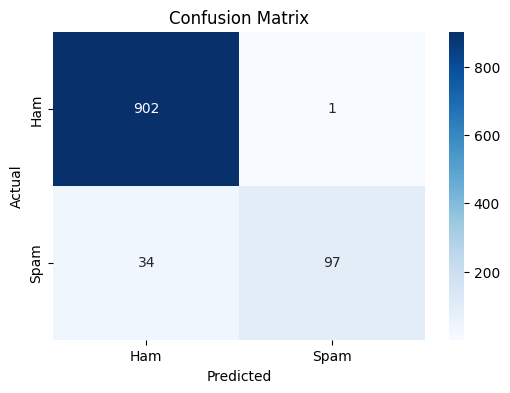

In [25]:
#graph
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Ham', 'Spam'],
    yticklabels=['Ham', 'Spam']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()

In [26]:
#Own message prediction
def predict_message(message):

    message_tfidf = vectorizer.transform([message])

    prediction = model.predict(message_tfidf)

    if prediction[0] == 1:
        return "SPAM"
    else:
        return "HAM"

In [27]:
#Spam message test
message = "Congratulations! You won a free iPhone. Click here to claim your prize!"

result = predict_message(message)

print("Message:", message)
print("Prediction:", result)

Message: Congratulations! You won a free iPhone. Click here to claim your prize!
Prediction: SPAM


In [28]:
#Normal message test
message = "Hi, are you coming to college tomorrow?"

result = predict_message(message)

print("Message:", message)
print("Prediction:", result)

Message: Hi, are you coming to college tomorrow?
Prediction: HAM


In [29]:
#Interactive Spam Filter
while True:

    message = input("Enter your message (type exit to stop): ")

    if message.lower() == "exit":
        print("Program stopped.")
        break

    result = predict_message(message)

    print("Prediction:", result)

Enter your message (type exit to stop): you got 1 crore rupees claim now
Prediction: HAM
Enter your message (type exit to stop): exit
Program stopped.
